# 📘 Notebook 01 — EDA & Preparação (Renda × Imóveis × Dívidas)

Este notebook é **exclusivamente** para **preparação e exploração** do dataset bruto.  
O Notebook 02 fará **AMNS (K-Means 3D)**.

**Variáveis contínuas-alvo:** `rtb_soma_centil`, `bens_imoveis`, `dividas_onus`  
**Entregáveis deste notebook:**  
1. `data/processed/distribuicao-renda-clean.csv` (completo, **limpo e padronizado**)  
2. `data/processed/distribuicao-renda-sample.csv` (**amostra 300–500** linhas comparável entre **dois anos** e **mesmos centis**)
3. `data/processed/metadata_preparo.json` (**metadados do preparo** — parâmetros, contagens, verificações, avisos)

> **Critério inicial de anos:** 2010 × 2020 — extremos de uma década para **maximizar contraste temporal**.  
> Se algum deles não estiver disponível ou tiver muita ausência de dados, o notebook **cai automaticamente** para o par **mais antigo × mais recente** disponível que passe no critério de qualidade.


## 1) Configuração do ambiente

In [1]:
%matplotlib inline
from __future__ import annotations
import unicodedata, re, os, json
from pathlib import Path
from typing import List, Tuple, Optional, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reprodutibilidade e formatação
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# Paths do projeto
ROOT = Path("..").resolve()
DATA_DIR = ROOT / "data"
RAW_PATH = DATA_DIR / "raw" / "distribuicao-renda.csv"
PROC_DIR = DATA_DIR / "processed"
PROC_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("RAW :", RAW_PATH)
print("PROC:", PROC_DIR)

ROOT: C:\Users\96207159187\Desktop\kmeans-3d-cluster
RAW : C:\Users\96207159187\Desktop\kmeans-3d-cluster\data\raw\distribuicao-renda.csv
PROC: C:\Users\96207159187\Desktop\kmeans-3d-cluster\data\processed


## 2) Parâmetros do experimento (editáveis)
- `ANOS_INICIAIS`: par-alvo preferencial (cairemos para o melhor par disponível se necessário)  
- `INTERVALO_CENTIL`: mesmo range em ambos os anos (garante comparabilidade)  
- `TARGET_SAMPLE`: alvo de linhas se a seleção ultrapassar 500 (downsampling estratificado por ano)  


In [2]:
ANOS_INICIAIS = [2010, 2020]   # preferido (cair para fallback se necessário)
INTERVALO_CENTIL = (1, 50)     # inclusivo (1..50)
TARGET_SAMPLE = 400            # se >500 linhas, reduza estratificando por ano para ~400

COLS_CONTINUAS_CANON = ['rtb_soma_centil', 'bens_imoveis', 'dividas_onus']

print("ANOS_INICIAIS:", ANOS_INICIAIS)
print("INTERVALO_CENTIL:", INTERVALO_CENTIL)
print("TARGET_SAMPLE:", TARGET_SAMPLE)
print("COLS_CONTINUAS_CANON:", COLS_CONTINUAS_CANON)

ANOS_INICIAIS: [2010, 2020]
INTERVALO_CENTIL: (1, 50)
TARGET_SAMPLE: 400
COLS_CONTINUAS_CANON: ['rtb_soma_centil', 'bens_imoveis', 'dividas_onus']


## 3) Utilidades (leitura robusta, normalização, detecção, métricas)

In [3]:
def read_csv_br(filepath: Path) -> pd.DataFrame:
    trials = [
        dict(sep=';', decimal=',', encoding='utf-8', engine='python'),
        dict(sep=',', decimal=',', encoding='utf-8', engine='python'),
        dict(sep=';', decimal='.', encoding='utf-8', engine='python'),
        dict(sep=',', decimal='.', encoding='utf-8', engine='python'),
        dict(sep=';', decimal=',', encoding='latin1', engine='python'),
        dict(sep=',', decimal=',', encoding='latin1', engine='python'),
    ]
    last_error = None
    for opts in trials:
        try:
            return pd.read_csv(filepath, **opts)
        except Exception as e:
            last_error = e
            continue
    raise ValueError(f"Não foi possível ler o CSV. Último erro: {last_error}")

def normalize_label(s: str) -> str:
    s = unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('ascii')
    s = s.strip().lower()
    s = re.sub(r'[^a-z0-9]+', '_', s)
    s = re.sub(r'_+', '_', s).strip('_')
    return s

def choose_col(cols_norm: List[str], must_have: List[str], also_has: Optional[List[str]]=None) -> Optional[str]:
    """Escolhe coluna por palavras-chave normalizadas.
    - must_have: TODAS as palavras precisam estar no nome
    - also_has: ao menos UMA deve aparecer (para desempate)
    """
    cands = [c for c in cols_norm if all(w in c for w in must_have)]
    if not cands:
        return None
    if also_has:
        for c in cands:
            if any(w in c for w in also_has):
                return c
    return cands[0]

def clean_numeric_locale(series: pd.Series) -> pd.Series:
    # remove milhar '.' e troca vírgula por ponto
    s = series.astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    return pd.to_numeric(s, errors='coerce')

def percent_nulls_by_year(df: pd.DataFrame, cols: List[str], anos: List[int]) -> pd.DataFrame:
    return (df[df['ano'].isin(anos)].groupby('ano')[cols].apply(lambda g: g.isna().mean().mul(100))).round(2)

def pick_year_pair(df: pd.DataFrame, prefer: List[int], cols: List[str], threshold: float = 5.0) -> Tuple[List[int], dict]:
    """Escolhe um par de anos:
    1) tenta 'prefer' (ex.: [2010, 2020]) se ambos existem e <= threshold de nulos em todas as cols
    2) senão, escolhe (min_year, max_year) disponíveis que passem no threshold
    3) se nenhum par passar, devolve (min_year, max_year) com aviso
    Retorna: [y1,y2], {'reason':..., 'warn':...}
    """
    info = {'reason': '', 'warn': ''}
    if 'ano' not in df.columns:
        info['warn'] = "Coluna 'ano' ausente após mapeamento/limpeza inicial."
        return prefer, info

    years = sorted([int(a) for a in df['ano'].dropna().unique()])
    if len(years) < 2:
        info['warn'] = "Menos de dois anos disponíveis no dataset."
        return years[:2], info

    def ok_pair(a, b):
        chk = percent_nulls_by_year(df, cols, [a, b])
        return not (chk > threshold).any().any(), chk

    # 1) tentar preferidos
    if all(y in years for y in prefer):
        good, chk = ok_pair(prefer[0], prefer[1])
        if good:
            info['reason'] = f"Anos preferidos aceitos ({prefer[0]} × {prefer[1]})."
            return prefer, info
        else:
            info['warn'] = f"Preferidos ({prefer[0]} × {prefer[1]}) têm >{threshold}% nulos em alguma variável. Tentando fallback."

    # 2) tentar extremos disponíveis
    y_min, y_max = years[0], years[-1]
    good, chk = ok_pair(y_min, y_max)
    if good:
        info['reason'] = f"Usando extremos disponíveis ({y_min} × {y_max})."
        return [y_min, y_max], info

    # 3) varrer combinações simples (primeiro válido)
    for a in years:
        for b in reversed(years):
            if a >= b:
                continue
            good, chk = ok_pair(a, b)
            if good:
                info['reason'] = f"Preferidos indisponíveis/ruins; escolhido primeiro par válido ({a} × {b})."
                return [a, b], info

    # 4) nenhum par passou no threshold — devolve extremos e avisa
    info['warn'] = f"Nenhum par de anos passou no threshold de {threshold}% de nulos. Usando extremos ({y_min} × {y_max})."
    return [y_min, y_max], info

def stratified_downsample_by_year(df: pd.DataFrame, target: int, random_state: int = 42) -> pd.DataFrame:
    if len(df) <= target:
        return df.copy()
    counts = df['ano'].value_counts(normalize=True).sort_index()
    alloc = (counts * target).round().astype(int)
    # ajustar soma exata
    diff = target - alloc.sum()
    if diff != 0:
        # distribuir o resto pelos maiores estratos
        idxs = alloc.sort_values(ascending=False).index.tolist()
        for i in range(abs(diff)):
            alloc[idxs[i % len(idxs)]] += 1 if diff > 0 else -1
    parts = []
    for ano, n in alloc.items():
        part = df[df['ano'] == ano]
        n = min(n, len(part))
        parts.append(part.sample(n=n, random_state=random_state))
    return pd.concat(parts, ignore_index=True)

## 4) Leitura do bruto + diagnóstico

In [4]:
df_raw = read_csv_br(RAW_PATH)

print("Shape bruto:", df_raw.shape)
display(df_raw.head(10))
print("\nColunas (brutas):", list(df_raw.columns))
print("\nTipos (bruto):"); display(df_raw.dtypes)
print("\nNulos (%) no bruto:"); display((df_raw.isna().mean()*100).round(2).sort_values(ascending=False))
print("\nDuplicatas (linhas idênticas no bruto):", df_raw.duplicated().sum())

Shape bruto: (46350, 24)


,Ano-calendário,Ente Federativo,Centil,Quantidade de Contribuintes,Rendimentos Tributaveis - Limite Superior da RTB do Centil [R$ milhões],Rendimentos Tributaveis - Soma da RTB do Centil [R$ milhões],Rendimentos Tributaveis - RTB Acumulada do Centil [R$ milhões],Rendimentos Tributaveis - Média da RTB do Centil [R$],Rendimentos Sujeitos à Tribut. Exclusiva [R$ milhões],Rendimentos Isentos - Lucros e dividendos [R$ milhões],Rendimentos Isentos - Rendim. Sócio/Titular ME/EPP Opt SIMPLES [R$ milhões],Rendimentos Isentos - Outros Rendimentos Isentos [R$ milhões],Despesas Dedutíveis - Previdência [R$ milhões],Despesas Dedutíveis - Dependentes [R$ milhões],Despesas Dedutíveis - Instrução [R$ milhões],Despesas Dedutíveis - Médicas [R$ milhões],Despesas Dedutíveis - Pensão Alimentícia [R$ milhões],Despesas Dedutíveis - Livro-Caixa [R$ milhões],Imposto Devido [R$ milhões],Bens e Direitos - Imóveis [R$ milhões],Bens e Direitos - Móveis [R$ milhões],Bens e Direitos - Financeiros [R$ milhões],Bens e Direitos - Outros Bens e Direitos [R$ milhões],Dívidas e Ônus [R$ milhões]
0,2006,BRASIL,1,241.563,NaN,NaN,NaN,NaN,235.61,481.27,27.37,"1.694,49",NaN,NaN,NaN,NaN,NaN,NaN,0.16,"5.281,59",686.21,"6.549,15","1.006,40","1.610,39"
1,2006,BRASIL,2,241.563,NaN,NaN,NaN,NaN,208.74,483.44,29.36,"1.675,01",NaN,NaN,NaN,NaN,NaN,NaN,0.22,"5.295,48",668.82,"5.762,77",681.75,694.12
2,2006,BRASIL,3,241.562,NaN,NaN,NaN,NaN,219.96,459.87,27.63,"1.683,04",NaN,NaN,NaN,NaN,NaN,NaN,0.31,"5.566,27",670.64,"5.451,95",377.17,650.98
3,2006,BRASIL,4,241.563,NaN,NaN,NaN,NaN,257.01,481.93,31.77,"1.699,89",NaN,NaN,NaN,NaN,NaN,NaN,0.17,"5.860,02",678.44,"6.104,09",256.16,"1.079,20"
4,2006,BRASIL,5,241.562,NaN,NaN,NaN,NaN,249.88,464.23,28.11,"1.697,17",NaN,NaN,NaN,NaN,NaN,NaN,0.17,"5.193,31",682.38,"5.592,52",269.28,671.97
5,2006,BRASIL,6,241.563,NaN,NaN,NaN,NaN,225.07,454.74,24.73,"1.604,68",NaN,NaN,NaN,NaN,NaN,NaN,0.13,"5.193,68",662.55,"6.611,62",265.35,612.02
6,2006,BRASIL,7,241.562,NaN,NaN,NaN,NaN,240.87,460.86,27.69,"1.608,30",NaN,NaN,NaN,NaN,NaN,NaN,0.08,"5.316,54",701.6,"5.652,74",389.85,863.93
7,2006,BRASIL,8,241.563,NaN,NaN,NaN,NaN,244.43,569.25,29.76,"1.751,91",NaN,NaN,NaN,NaN,NaN,NaN,0.1,"5.443,09",673.85,"6.197,00",336.04,629.92
8,2006,BRASIL,9,241.562,NaN,NaN,NaN,NaN,176.14,536.98,24.94,"1.581,53",NaN,NaN,NaN,NaN,NaN,NaN,0.21,"5.274,17",658.96,"5.903,26",232.22,933.64
9,2006,BRASIL,10,241.563,NaN,NaN,NaN,NaN,259.26,547.41,30.08,"1.756,96",NaN,NaN,NaN,NaN,NaN,NaN,0.16,"5.219,60",687.21,"5.627,35",281.04,685.59



Colunas (brutas): ['Ano-calendário', 'Ente Federativo', 'Centil', 'Quantidade de Contribuintes', 'Rendimentos Tributaveis - Limite Superior da RTB do Centil [R$ milhões]', 'Rendimentos Tributaveis - Soma da RTB do Centil [R$ milhões]', 'Rendimentos Tributaveis - RTB Acumulada do Centil [R$ milhões]', 'Rendimentos Tributaveis - Média da RTB do Centil [R$]', 'Rendimentos Sujeitos à Tribut. Exclusiva [R$ milhões]', 'Rendimentos Isentos - Lucros e dividendos [R$ milhões]', 'Rendimentos Isentos - Rendim. Sócio/Titular ME/EPP Opt SIMPLES [R$ milhões]', 'Rendimentos Isentos - Outros Rendimentos Isentos [R$ milhões]', 'Despesas Dedutíveis - Previdência [R$ milhões]', 'Despesas Dedutíveis - Dependentes [R$ milhões]', 'Despesas Dedutíveis - Instrução [R$ milhões]', 'Despesas Dedutíveis - Médicas [R$ milhões]', 'Despesas Dedutíveis - Pensão Alimentícia [R$ milhões]', 'Despesas Dedutíveis - Livro-Caixa [R$ milhões]', 'Imposto Devido [R$ milhões]', 'Bens e Direitos - Imóveis [R$ milhões]', 'Bens e

Ano-calendário                                                                   int64
Ente Federativo                                                                 object
Centil                                                                          object
Quantidade de Contribuintes                                                    float64
Rendimentos Tributaveis - Limite Superior da RTB do Centil [R$ milhões]         object
Rendimentos Tributaveis - Soma da RTB do Centil [R$ milhões]                    object
Rendimentos Tributaveis - RTB Acumulada do Centil [R$ milhões]                  object
Rendimentos Tributaveis - Média da RTB do Centil [R$]                           object
Rendimentos Sujeitos à Tribut. Exclusiva [R$ milhões]                           object
Rendimentos Isentos - Lucros e dividendos [R$ milhões]                          object
Rendimentos Isentos - Rendim. Sócio/Titular ME/EPP Opt SIMPLES [R$ milhões]     object
Rendimentos Isentos - Outros Rendimentos Is


Nulos (%) no bruto:


Imposto Devido [R$ milhões]                                                   17.620
Despesas Dedutíveis - Livro-Caixa [R$ milhões]                                14.580
Despesas Dedutíveis - Pensão Alimentícia [R$ milhões]                          8.420
Despesas Dedutíveis - Instrução [R$ milhões]                                   7.800
Despesas Dedutíveis - Médicas [R$ milhões]                                     7.510
Despesas Dedutíveis - Previdência [R$ milhões]                                 7.400
Despesas Dedutíveis - Dependentes [R$ milhões]                                 7.390
Rendimentos Tributaveis - Limite Superior da RTB do Centil [R$ milhões]        7.370
Rendimentos Tributaveis - Soma da RTB do Centil [R$ milhões]                   7.370
Rendimentos Tributaveis - RTB Acumulada do Centil [R$ milhões]                 7.370
Rendimentos Tributaveis - Média da RTB do Centil [R$]                          7.370
Rendimentos Isentos - Rendim. Sócio/Titular ME/EPP Opt SIMPLES [R


Duplicatas (linhas idênticas no bruto): 0


## 5) Normalização de rótulos (pré-mapeamento)

In [5]:
df_norm = df_raw.rename(columns={c: normalize_label(str(c)) for c in df_raw.columns})
print("Colunas normalizadas (amostra):", list(df_norm.columns)[:14], "...")

Colunas normalizadas (amostra): ['ano_calendario', 'ente_federativo', 'centil', 'quantidade_de_contribuintes', 'rendimentos_tributaveis_limite_superior_da_rtb_do_centil_r_milhoes', 'rendimentos_tributaveis_soma_da_rtb_do_centil_r_milhoes', 'rendimentos_tributaveis_rtb_acumulada_do_centil_r_milhoes', 'rendimentos_tributaveis_media_da_rtb_do_centil_r', 'rendimentos_sujeitos_a_tribut_exclusiva_r_milhoes', 'rendimentos_isentos_lucros_e_dividendos_r_milhoes', 'rendimentos_isentos_rendim_socio_titular_me_epp_opt_simples_r_milhoes', 'rendimentos_isentos_outros_rendimentos_isentos_r_milhoes', 'despesas_dedutiveis_previdencia_r_milhoes', 'despesas_dedutiveis_dependentes_r_milhoes'] ...


## 6) Mapeamento dinâmico → esquema canônico
Detecta automaticamente as colunas-alvo mesmo com variações de nomes:
- `ano` ∈ {`ano_calendario`, `ano`}  
- `uf` ∈ {`ente_federativo`, `uf`}  
- `centil` = `centil`  
- `rtb_soma_centil` (padrões com `'rtb'` e `'soma'` ou `'soma_da_rtb'`)  
- `bens_imoveis` (padrões com `'imoveis'` e preferencialmente `'bens'`/`'direitos'`)  
- `dividas_onus` (padrões com `'dividas'` e `'onus'`)

In [6]:
cols_norm = list(df_norm.columns)

# chaves
col_ano = 'ano' if 'ano' in cols_norm else ('ano_calendario' if 'ano_calendario' in cols_norm else None)
col_uf = 'uf' if 'uf' in cols_norm else ('ente_federativo' if 'ente_federativo' in cols_norm else None)
col_centil = 'centil' if 'centil' in cols_norm else None

# rtb_soma_centil
cands_rtb = [
    choose_col(cols_norm, must_have=['rtb','soma']),
    choose_col(cols_norm, must_have=['soma','rtb']),
    choose_col(cols_norm, must_have=['soma','da','rtb']),
    'rtb_soma_centil' if 'rtb_soma_centil' in cols_norm else None,
]
col_rtb = next((c for c in cands_rtb if c), None)

# bens_imoveis
col_imoveis = choose_col(cols_norm, must_have=['imoveis'], also_has=['bens','direitos'])               or choose_col(cols_norm, must_have=['bens','imoveis'])               or ('bens_imoveis' if 'bens_imoveis' in cols_norm else None)

# dividas_onus
col_dividas = choose_col(cols_norm, must_have=['dividas','onus'])               or ('dividas_e_onus_r_milhoes' if 'dividas_e_onus_r_milhoes' in cols_norm else None)               or ('dividas_onus' if 'dividas_onus' in cols_norm else None)

mapping_dynamic: Dict[str,str] = {}
if col_ano: mapping_dynamic[col_ano] = 'ano'
if col_uf: mapping_dynamic[col_uf] = 'uf'
if col_centil: mapping_dynamic[col_centil] = 'centil'
if col_rtb: mapping_dynamic[col_rtb] = 'rtb_soma_centil'
if col_imoveis: mapping_dynamic[col_imoveis] = 'bens_imoveis'
if col_dividas: mapping_dynamic[col_dividas] = 'dividas_onus'

df = df_norm.rename(columns=mapping_dynamic)

esperadas = {'ano','uf','centil','rtb_soma_centil','bens_imoveis','dividas_onus'}
faltando = [c for c in esperadas if c not in df.columns]
print("🔎 Detecção dinâmica:")
print("  ano:", col_ano, "→", 'ano' if col_ano else None)
print("  uf:", col_uf, "→", 'uf' if col_uf else None)
print("  centil:", col_centil, "→", 'centil' if col_centil else None)
print("  rtb_soma_centil:", col_rtb, "→", 'rtb_soma_centil' if col_rtb else None)
print("  bens_imoveis:", col_imoveis, "→", 'bens_imoveis' if col_imoveis else None)
print("  dividas_onus:", col_dividas, "→", 'dividas_onus' if col_dividas else None)

if faltando:
    print("⚠️ Colunas esperadas não encontradas:", faltando)
    print("Colunas disponíveis:", list(df.columns))
    raise ValueError("Mapeamento de colunas incompleto — ajuste as regras de detecção acima.")
else:
    print("✅ Mapeamento OK:", esperadas)
    display(df.head(5))

🔎 Detecção dinâmica:
  ano: ano_calendario → ano
  uf: ente_federativo → uf
  centil: centil → centil
  rtb_soma_centil: rendimentos_tributaveis_soma_da_rtb_do_centil_r_milhoes → rtb_soma_centil
  bens_imoveis: bens_e_direitos_imoveis_r_milhoes → bens_imoveis
  dividas_onus: dividas_e_onus_r_milhoes → dividas_onus
✅ Mapeamento OK: {'uf', 'dividas_onus', 'bens_imoveis', 'rtb_soma_centil', 'ano', 'centil'}


,ano,uf,centil,quantidade_de_contribuintes,rendimentos_tributaveis_limite_superior_da_rtb_do_centil_r_milhoes,rtb_soma_centil,rendimentos_tributaveis_rtb_acumulada_do_centil_r_milhoes,rendimentos_tributaveis_media_da_rtb_do_centil_r,rendimentos_sujeitos_a_tribut_exclusiva_r_milhoes,rendimentos_isentos_lucros_e_dividendos_r_milhoes,rendimentos_isentos_rendim_socio_titular_me_epp_opt_simples_r_milhoes,rendimentos_isentos_outros_rendimentos_isentos_r_milhoes,despesas_dedutiveis_previdencia_r_milhoes,despesas_dedutiveis_dependentes_r_milhoes,despesas_dedutiveis_instrucao_r_milhoes,despesas_dedutiveis_medicas_r_milhoes,despesas_dedutiveis_pensao_alimenticia_r_milhoes,despesas_dedutiveis_livro_caixa_r_milhoes,imposto_devido_r_milhoes,bens_imoveis,bens_e_direitos_moveis_r_milhoes,bens_e_direitos_financeiros_r_milhoes,bens_e_direitos_outros_bens_e_direitos_r_milhoes,dividas_onus
0,2006,BRASIL,1,241.563,NaN,NaN,NaN,NaN,235.61,481.27,27.37,"1.694,49",NaN,NaN,NaN,NaN,NaN,NaN,0.16,"5.281,59",686.21,"6.549,15","1.006,40","1.610,39"
1,2006,BRASIL,2,241.563,NaN,NaN,NaN,NaN,208.74,483.44,29.36,"1.675,01",NaN,NaN,NaN,NaN,NaN,NaN,0.22,"5.295,48",668.82,"5.762,77",681.75,694.12
2,2006,BRASIL,3,241.562,NaN,NaN,NaN,NaN,219.96,459.87,27.63,"1.683,04",NaN,NaN,NaN,NaN,NaN,NaN,0.31,"5.566,27",670.64,"5.451,95",377.17,650.98
3,2006,BRASIL,4,241.563,NaN,NaN,NaN,NaN,257.01,481.93,31.77,"1.699,89",NaN,NaN,NaN,NaN,NaN,NaN,0.17,"5.860,02",678.44,"6.104,09",256.16,"1.079,20"
4,2006,BRASIL,5,241.562,NaN,NaN,NaN,NaN,249.88,464.23,28.11,"1.697,17",NaN,NaN,NaN,NaN,NaN,NaN,0.17,"5.193,31",682.38,"5.592,52",269.28,671.97


## 7) EDA **ANTES** da limpeza (visual do bruto)

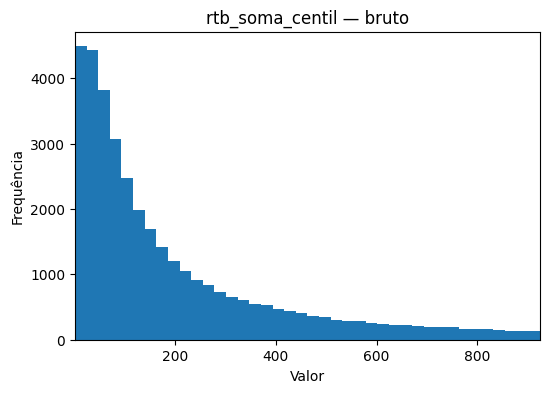

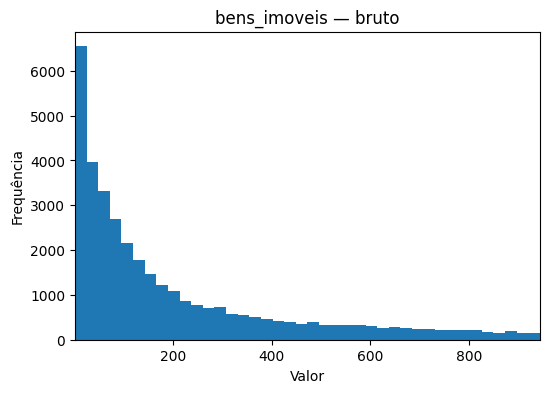

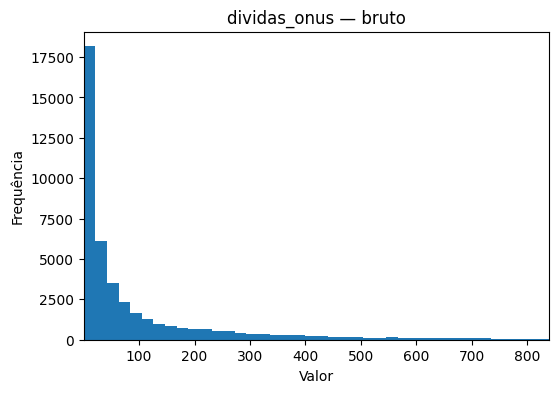

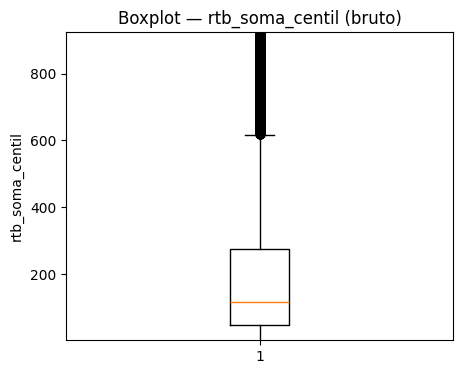

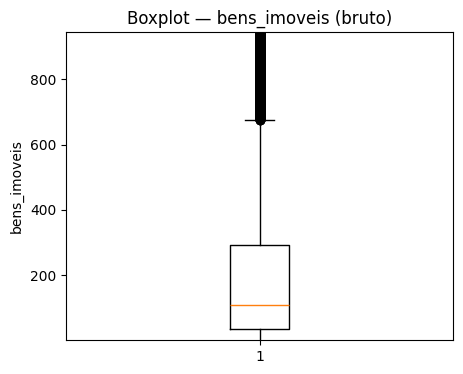

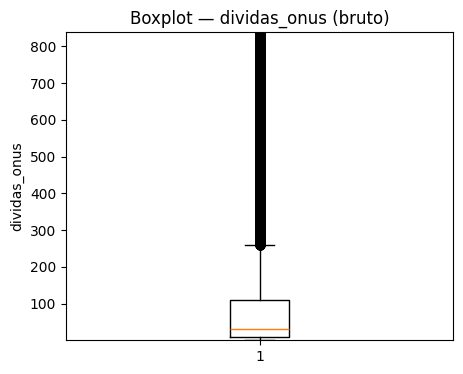

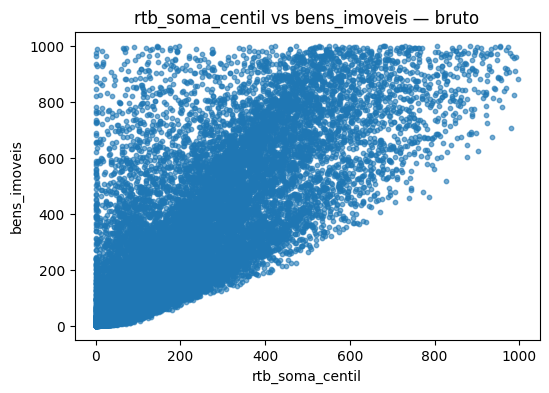

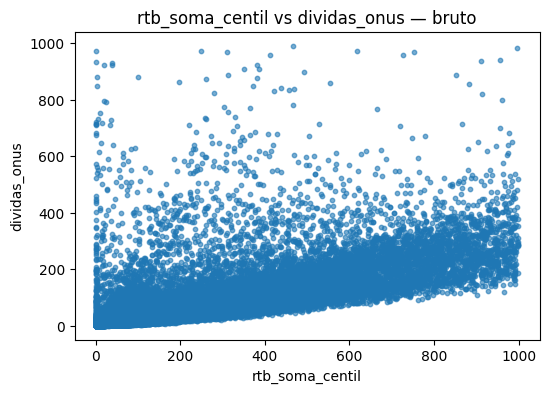

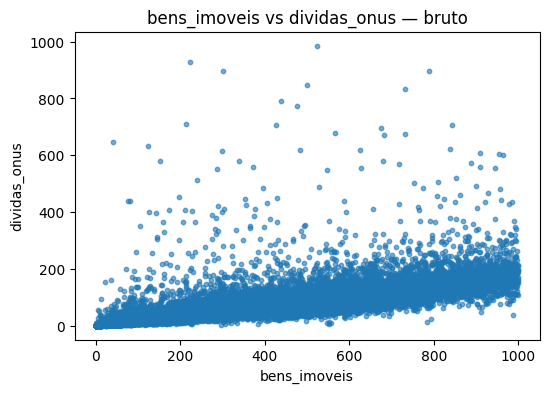

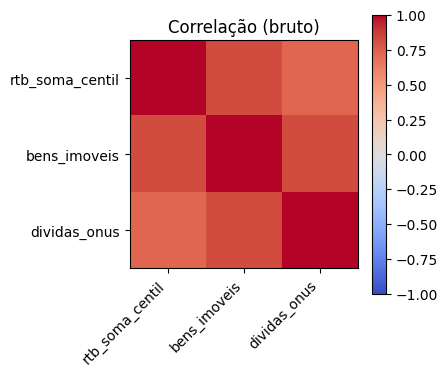

In [7]:
CONTINUAS = ['rtb_soma_centil','bens_imoveis','dividas_onus']

# Calcular limites comuns (1º–99º percentis) para comparar ANTES vs DEPOIS
limits = {}
bins_dict = {}
for c in CONTINUAS:
    s_raw = pd.to_numeric(df[c], errors='coerce').dropna()
    if s_raw.empty: 
        print(f"[BRUTO] Sem dados numéricos em {c}.")
        continue
    lo, hi = np.nanpercentile(s_raw, 1), np.nanpercentile(s_raw, 99)
    if lo == hi:
        lo, hi = s_raw.min(), s_raw.max()
    limits[c] = (lo, hi)
    bins_dict[c] = np.linspace(lo, hi, 41)

# Histogramas (bruto)
for c in CONTINUAS:
    if c not in limits: continue
    s = pd.to_numeric(df[c], errors='coerce').dropna()
    plt.figure(figsize=(6,4)); plt.hist(s, bins=bins_dict[c])
    plt.title(f"{c} — bruto"); plt.xlabel("Valor"); plt.ylabel("Frequência"); plt.xlim(*limits[c]); plt.show()

# Boxplots (bruto) com mesmos limites
for c in CONTINUAS:
    if c not in limits: continue
    s = pd.to_numeric(df[c], errors='coerce').dropna()
    plt.figure(figsize=(5,4)); plt.boxplot(s, vert=True, whis=1.5)
    plt.title(f"Boxplot — {c} (bruto)"); plt.ylabel(c); plt.ylim(*limits[c]); plt.show()

# Scatter (bruto)
pairs = [(CONTINUAS[i], CONTINUAS[j]) for i in range(len(CONTINUAS)) for j in range(i+1,len(CONTINUAS))]
for (x,y) in pairs:
    sx = pd.to_numeric(df[x], errors='coerce')
    sy = pd.to_numeric(df[y], errors='coerce')
    m = sx.notna() & sy.notna()
    if m.sum()==0: continue
    plt.figure(figsize=(6,4)); plt.scatter(sx[m], sy[m], s=10, alpha=0.6)
    plt.xlabel(x); plt.ylabel(y); plt.title(f"{x} vs {y} — bruto"); plt.show()

# Correlação (bruto)
tmp = df[CONTINUAS].apply(lambda s: pd.to_numeric(s, errors='coerce'))
if tmp.dropna().shape[0] > 0:
    corr = tmp.corr(method='pearson')
    plt.figure(figsize=(4.5,4)); plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1); plt.colorbar()
    plt.xticks(range(len(CONTINUAS)), CONTINUAS, rotation=45, ha='right'); plt.yticks(range(len(CONTINUAS)), CONTINUAS)
    plt.title("Correlação (bruto)"); plt.tight_layout(); plt.show()

### 🔎 Decisão #1 (após EDA do bruto)
- Liste aqui o que limpar (locale BR, duplicatas, linhas sem chaves, etc.).
- Registre qualquer comportamento anômalo por ano/UF para investigar na limpeza.


## 8) Limpeza & Tipagem

In [8]:
# Tipos-chave
df['ano'] = pd.to_numeric(df['ano'], errors='coerce').astype('Int64')
df['centil'] = pd.to_numeric(df['centil'], errors='coerce')

# Locale BR nas contínuas
for c in CONTINUAS:
    df[c] = clean_numeric_locale(df[c])

# Remover linhas sem chaves mínimas
before = len(df)
df = df.dropna(subset=['ano','uf','centil'])
after = len(df)
print(f"Removidas {before - after} linhas sem chaves mínimas (ano/uf/centil).")

# Duplicatas exatas
dup = df.duplicated().sum()
if dup: 
    df = df.drop_duplicates(); print(f"Removidas {dup} duplicatas.")
else:
    print("Sem duplicatas exatas.")

Removidas 150 linhas sem chaves mínimas (ano/uf/centil).
Sem duplicatas exatas.


## 9) EDA **DEPOIS** da limpeza (visual do limpo)

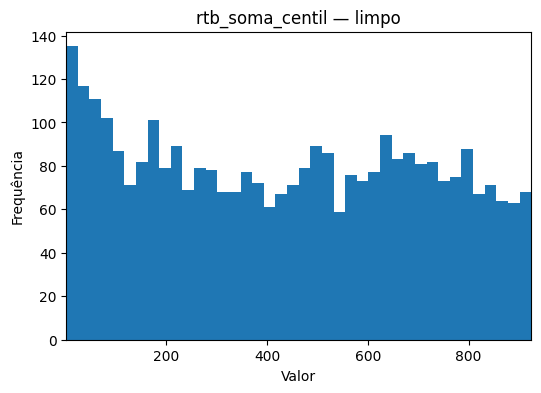

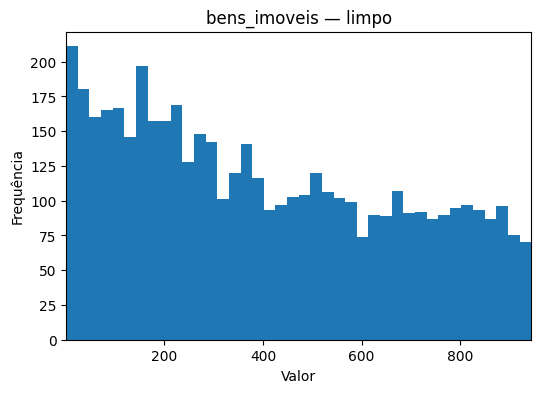

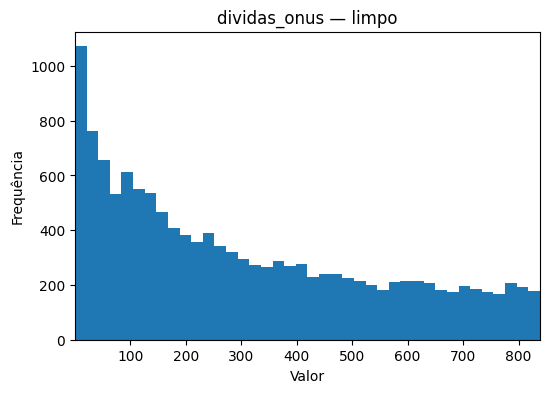

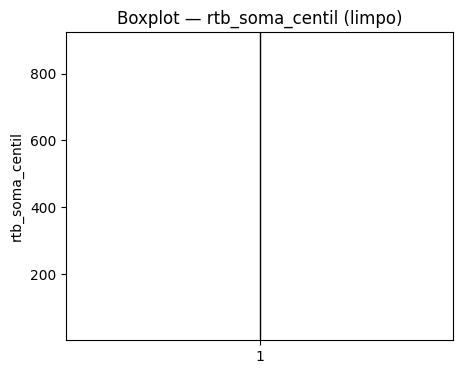

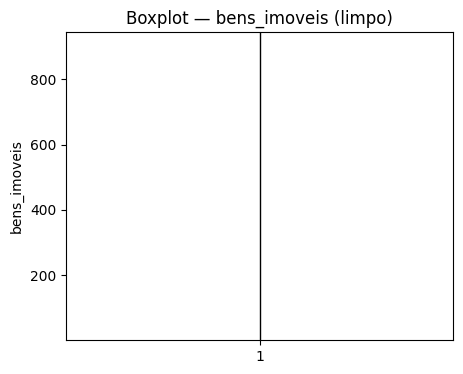

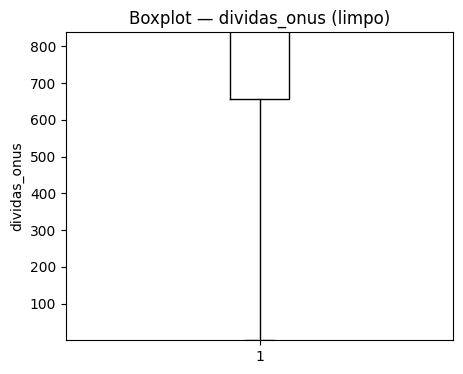

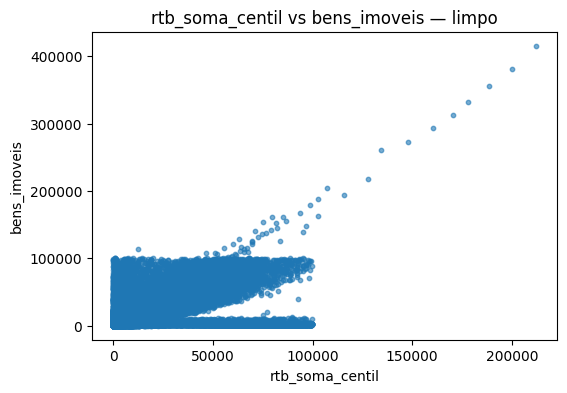

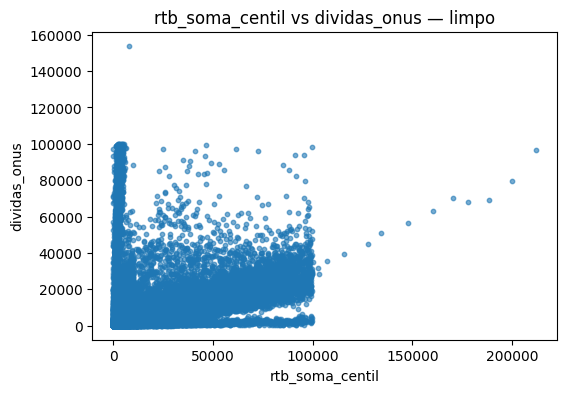

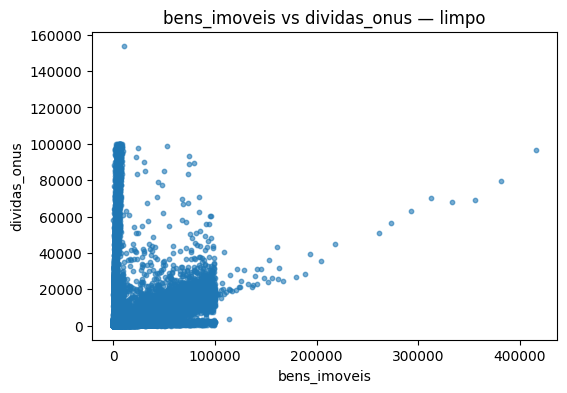

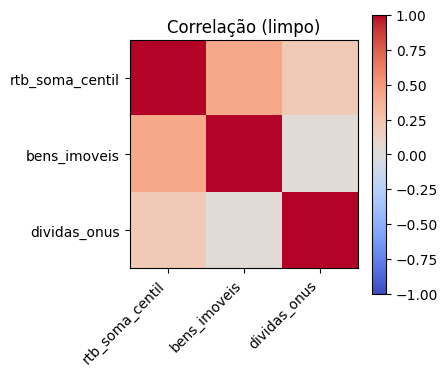

In [9]:
# Histogramas (limpo) com mesmos limites/bins do bruto
for c in CONTINUAS:
    if c not in limits: continue
    s = df[c].dropna()
    if s.empty: 
        print(f"[LIMPO] Sem dados numéricos em {c}."); 
        continue
    plt.figure(figsize=(6,4)); plt.hist(s, bins=bins_dict[c])
    plt.title(f"{c} — limpo"); plt.xlabel("Valor"); plt.ylabel("Frequência"); plt.xlim(*limits[c]); plt.show()

# Boxplots (limpo)
for c in CONTINUAS:
    if c not in limits: continue
    s = df[c].dropna()
    if s.empty: continue
    plt.figure(figsize=(5,4)); plt.boxplot(s, vert=True, whis=1.5)
    plt.title(f"Boxplot — {c} (limpo)"); plt.ylabel(c); plt.ylim(*limits[c]); plt.show()

# Scatter (limpo)
pairs = [(CONTINUAS[i], CONTINUAS[j]) for i in range(len(CONTINUAS)) for j in range(i+1,len(CONTINUAS))]
for (x,y) in pairs:
    sx, sy = df[x], df[y]
    m = sx.notna() & sy.notna()
    if m.sum()==0: continue
    plt.figure(figsize=(6,4)); plt.scatter(sx[m], sy[m], s=10, alpha=0.6)
    plt.xlabel(x); plt.ylabel(y); plt.title(f"{x} vs {y} — limpo"); plt.show()

# Correlação (limpo)
tmp = df[CONTINUAS].dropna()
if tmp.shape[0] > 0:
    corr = tmp.corr(method='pearson')
    plt.figure(figsize=(4.5,4)); plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1); plt.colorbar()
    plt.xticks(range(len(CONTINUAS)), CONTINUAS, rotation=45, ha='right'); plt.yticks(range(len(CONTINUAS)), CONTINUAS)
    plt.title("Correlação (limpo)"); plt.tight_layout(); plt.show()

### 🔎 Decisão #2 (após EDA do limpo)
- Confirme que as 3 variáveis estão aptas para o Notebook 02.
- Comente se ainda há outliers a tratar na modelagem (padronização/robustez).


## 10) Sanidade dos anos & escolha automática do par

In [10]:
# Tenta usar ANOS_INICIAIS; se rejeitados, escolhe melhor par disponível (threshold=5% de nulos)
quality_cols = CONTINUAS
pair, info = pick_year_pair(df, ANOS_INICIAIS, quality_cols, threshold=5.0)
print("Par de anos escolhido:", pair)
print("Motivo:", info.get('reason',''))
if info.get('warn'): print("Aviso:", info['warn'])

# Checagem de nulos por ano para o par escolhido
check = percent_nulls_by_year(df, quality_cols, pair)
print("Percentual de nulos (%) por variável nos anos escolhidos:")
display(check)

Par de anos escolhido: [2006, 2020]
Motivo: 
Aviso: Nenhum par de anos passou no threshold de 5.0% de nulos. Usando extremos (2006 × 2020).
Percentual de nulos (%) por variável nos anos escolhidos:


,rtb_soma_centil,bens_imoveis,dividas_onus
ano,,,
2006,12.310,1.330,2.760
2020,5.550,0.000,0.000


## 11) Amostragem comparável (interseção UF×centil) + downsampling

In [11]:
# Filtro básico por anos e centil
mask_ano = df['ano'].isin(pair)
mask_centil = df['centil'].between(INTERVALO_CENTIL[0], INTERVALO_CENTIL[1])
base = df[mask_ano & mask_centil].copy()

# Interseção de (UF, centil) presente em ambos os anos
if not base.empty:
    a, b = pair
    comb_a = set(tuple(x) for x in base.loc[base['ano']==a, ['uf','centil']].dropna().values.tolist())
    comb_b = set(tuple(x) for x in base.loc[base['ano']==b, ['uf','centil']].dropna().values.tolist())
    inter = comb_a & comb_b
    if inter:
        mask_inter = base[['uf','centil']].apply(tuple, axis=1).isin(inter)
        base = base[mask_inter].copy()
        used_intersection = True
    else:
        print("⚠️ Não há interseção UF×centil entre os anos; seguindo sem a restrição de interseção.")
        used_intersection = False
else:
    used_intersection = False

print("Shape após filtro anos+centis(+interseção):", base.shape)
print("\nContagem por ano:"); display(base['ano'].value_counts().sort_index())

# Downsampling se >500 (estratificado por ano) → target ~TARGET_SAMPLE
if len(base) > 500:
    base_ds = stratified_downsample_by_year(base, target=TARGET_SAMPLE, random_state=RANDOM_SEED)
    print(f"Aplicado downsampling estratificado por ano para ~{TARGET_SAMPLE} linhas. Novo shape:", base_ds.shape)
else:
    base_ds = base.copy()

df_sample = base_ds.reset_index(drop=True)

Shape após filtro anos+centis(+interseção): (2800, 24)

Contagem por ano:


ano
2006    1400
2020    1400
Name: count, dtype: Int64

Aplicado downsampling estratificado por ano para ~400 linhas. Novo shape: (400, 24)


## 12) Persistência dos artefatos + metadados do preparo

In [12]:
## 12) Persistência dos artefatos + metadados do preparo (corrigido)
from datetime import datetime
import numpy as np
import pandas as pd
import json

# Garante diretório
PROC_DIR.mkdir(parents=True, exist_ok=True)

clean_path = PROC_DIR / 'distribuicao-renda-clean.csv'
sample_path = PROC_DIR / 'distribuicao-renda-sample.csv'
meta_path  = PROC_DIR / 'metadata_preparo.json'

# Salvar CSVs (encoding explícito ajuda no Windows/Excel)
df.to_csv(clean_path, index=False, encoding='utf-8')
df_sample.to_csv(sample_path, index=False, encoding='utf-8')

# Helper: converte numpy/pandas -> tipos Python nativos para JSON
def to_py(x):
    if isinstance(x, (np.integer,)):  return int(x)
    if isinstance(x, (np.floating,)): return float(x)
    if isinstance(x, (np.bool_,)):    return bool(x)
    if pd.isna(x):                    return None
    return x

# Percentual de nulos por ano (em tipos nativos)
pn = percent_nulls_by_year(df, CONTINUAS, pair).astype(float).round(2)
pn_idx = pn.to_dict(orient='index')  # {ano: {variavel: valor}}
pn_native = {int(yr): {str(k): to_py(v) for k, v in row.items()} for yr, row in pn_idx.items()}

# Contagem por ano da amostra (nativo)
sample_counts_native = {int(k): int(v) for k, v in df_sample['ano'].value_counts().sort_index().to_dict().items()}

metadata = {
    "generated_at": datetime.utcnow().isoformat() + "Z",
    "anos_iniciais": [int(x) for x in ANOS_INICIAIS],
    "anos_escolhidos": [int(x) for x in pair],
    "intervalo_centil": [int(INTERVALO_CENTIL[0]), int(INTERVALO_CENTIL[1])],
    "usou_intersecao_uf_centil": bool('used_intersection' in locals() and used_intersection),
    "sample_size": int(len(df_sample)),
    "sample_counts_por_ano": sample_counts_native,
    "total_clean": int(len(df)),
    "total_raw": int(len(df_raw)),
    "duplicatas_removidas": int(df_raw.duplicated().sum()),
    "percent_nulos_por_ano_escolhido": pn_native,
    "random_seed": int(RANDOM_SEED),
}

with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Arquivos salvos com sucesso:")
print("-", clean_path.resolve())
print("-", sample_path.resolve())
print("-", meta_path.resolve())


Arquivos salvos com sucesso:
- C:\Users\96207159187\Desktop\kmeans-3d-cluster\data\processed\distribuicao-renda-clean.csv
- C:\Users\96207159187\Desktop\kmeans-3d-cluster\data\processed\distribuicao-renda-sample.csv
- C:\Users\96207159187\Desktop\kmeans-3d-cluster\data\processed\metadata_preparo.json


C:\Users\96207159187\AppData\Local\Temp\ipykernel_13180\2074849532.py:35: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "generated_at": datetime.utcnow().isoformat() + "Z",


## 13) Sumário & Próximos passos
- EDA **antes** e **depois** da limpeza com **mesmos limites** para comparação direta.  
- Mapeamento **dinâmico** das colunas com verificação explicativa.  
- Escolha automática do **par de anos** com verificação de **nulos** (threshold 5%).  
- Amostragem **comparável** pela **interseção UF×centil** entre anos; **downsampling estratificado** se >500.  
- Persistência de `clean`, `sample` e `metadata_preparo.json`.

**Notebook 02 (AMNS — K-Means 3D):**
- Padronização (z-score) das 3 variáveis;
- Seleção de *k*: Elbow, Silhouette, Calinski-Harabasz, Davies-Bouldin;
- **Gráficos de teia (radar)** para comparar *k*;
- Treino final do K-Means, 3D dos clusters, radar de perfil por cluster;
- Export dos rótulos, centróides (z e escala original) e modelo.
